In [2]:
import pandas as pd
import numpy as np
import random
from faker import Faker
fake = Faker()

In [3]:
#generation of random people and their pronouns,
pronoun_groups = [
    "she/her",
    "he/him",
    "they/them",
    "xe/xer",
    "she/they",
    "he/they"
    
]
alpha = np.array([5.0, 5.0, 2.0, 0.5, 1.0, 1.0])
number_of_people = 300

# Each person gets their own Dirichlet draw = continuous pronoun affinity vector
np.random.seed(42)
affinity_matrix = np.random.dirichlet(alpha, size=number_of_people)

#additional Guassian noise
noise = np.abs(np.random.normal(0, 0.02, affinity_matrix.shape))
affinity_matrix = affinity_matrix + noise
affinity_matrix = affinity_matrix / affinity_matrix.sum(axis=1, keepdims=True)

primary_pronouns = [
    np.random.choice(pronoun_groups, p=affinity_matrix[i])
    for i in range(number_of_people)
]

people = pd.DataFrame({
    "ID":range(1, number_of_people + 1),
    "Name": [fake.name() for _ in range(number_of_people)],
    "Pronouns": primary_pronouns,
    **{f"affinity_{pg.replace('/','_')}": affinity_matrix[:, j]
       for j, pg in enumerate(pronoun_groups)}
})
people.head()

,ID,Name,Pronouns,affinity_she_her,affinity_he_him,affinity_they_them,affinity_xe_xer,affinity_she_they,affinity_he_they
0,1,Jason Chapman,xe/xer,0.406644,0.291097,0.099959,0.107525,0.090097,0.004678
1,2,Marissa Hahn,he/they,0.334204,0.327193,0.207026,0.029623,0.055263,0.046691
2,3,Jack Ryan,he/they,0.198134,0.372973,0.314028,0.031126,0.017337,0.066402
3,4,Jacob Simon,she/her,0.342072,0.303781,0.117650,0.015557,0.004310,0.216629
4,5,Susan Fernandez,she/they,0.459155,0.184569,0.057818,0.067571,0.160450,0.070437


In [4]:
connective_lst = []

for i, person_id in enumerate(people["ID"]):
    number_of_connections = random.randint(1, 3)
    
    # Compute affinity similarity to all others (dot product = cosine-like weight)
    person_vec = affinity_matrix[i]
    other_ids = [pid for pid in people["ID"] if pid != person_id]
    other_indices = [pid - 1 for pid in other_ids]
    
    # Similarity weights: dot product between this person's affinity and all others
    weights = affinity_matrix[other_indices] @ person_vec
    
    # Add noise to weights so it's not purely deterministic
    weights += np.abs(np.random.normal(0, 0.01, len(weights)))
    weights = weights / weights.sum()  # normalize to probabilities
    
    connect_ids = np.random.choice(other_ids, size=number_of_connections,
                                   replace=False, p=weights)
    
    for conid in connect_ids:
        connective_lst.append({"FromID": person_id, "ToID": int(conid)})

connections = pd.DataFrame(connective_lst)
connections.head()

,FromID,ToID
0,1,52
1,1,240
2,1,216
3,2,163
4,3,152


In [5]:
#merging both people and pronouns into a singular excel sheet
affinity_cols = [c for c in people.columns if c.startswith("affinity_")]

merging = connections.merge(
    people, left_on="FromID", right_on="ID"
).merge(
    people, left_on="ToID", right_on="ID", suffixes=("_From", "_To")
)

final = merging[[
    "Name_From", "Pronouns_From", *[f"{c}_From" for c in affinity_cols],
    "Name_To", "Pronouns_To", *[f"{c}_To" for c in affinity_cols]
]]
final.head()

,Name_From,Pronouns_From,affinity_she_her_From,affinity_he_him_From,affinity_they_them_From,affinity_xe_xer_From,affinity_she_they_From,affinity_he_they_From,Name_To,Pronouns_To,affinity_she_her_To,affinity_he_him_To,affinity_they_them_To,affinity_xe_xer_To,affinity_she_they_To,affinity_he_they_To
0,Jason Chapman,xe/xer,0.406644,0.291097,0.099959,0.107525,0.090097,0.004678,Don Green,she/her,0.607733,0.205325,0.021113,0.042351,0.046438,0.077041
1,Jason Chapman,xe/xer,0.406644,0.291097,0.099959,0.107525,0.090097,0.004678,Nathaniel Williams,she/they,0.388112,0.433052,0.103688,0.004747,0.054853,0.015547
2,Jason Chapman,xe/xer,0.406644,0.291097,0.099959,0.107525,0.090097,0.004678,Tammy Williams,she/her,0.385784,0.245991,0.172833,0.041856,0.072797,0.080739
3,Marissa Hahn,he/they,0.334204,0.327193,0.207026,0.029623,0.055263,0.046691,Larry Hall,they/them,0.443682,0.306646,0.115257,0.068434,0.040529,0.025453
4,Jack Ryan,he/they,0.198134,0.372973,0.314028,0.031126,0.017337,0.066402,Christopher Reynolds,she/her,0.318763,0.325799,0.112403,0.099834,0.063553,0.079649


In [6]:
# Map primary pronoun to user group label (for grouping/analysis)
def map_user_group(pronoun_str):
    pronoun_str = pronoun_str.lower()
    if pronoun_str in ["he/him", "he"]:
        return "he"
    elif pronoun_str in ["she/her", "she"]:
        return "she"
    elif pronoun_str in ["they/them", "they"]:
        return "they"
    elif pronoun_str in ["xe/xer", "xe"]:
        return "xe"
    elif pronoun_str in ["she/they"]:
        return "she/they"
    elif pronoun_str in ["he/they"]:
        return "he/they"
    else:
        return pronoun_str

people["User_Group"] = people["Pronouns"].apply(map_user_group)

# Explode into base pronoun rows for probability matrix
people["Base_Pronoun_List"] = people["User_Group"].apply(lambda x: x.split("/"))
exploded = people.explode("Base_Pronoun_List")

# Build probability matrix from sampled primary pronouns
pronoun_matrix = pd.crosstab(
    exploded["User_Group"],
    exploded["Base_Pronoun_List"],
    normalize="index"
)

pronoun_matrix = pronoun_matrix.reindex(
    columns=["he", "she", "they", "xe"], fill_value=0
)

group_counts = people["User_Group"].value_counts()
pronoun_matrix["User_Count"] = group_counts

cols = ["User_Count"] + [col for col in pronoun_matrix.columns if col != "User_Count"]
pronoun_matrix = pronoun_matrix[cols]

pronoun_matrix

Base_Pronoun_List,User_Count,he,she,they,xe
User_Group,,,,,
he,94,1.0,0.0,0.0,0.0
he/they,27,0.5,0.0,0.5,0.0
she,96,0.0,1.0,0.0,0.0
she/they,18,0.0,0.5,0.5,0.0
they,48,0.0,0.0,1.0,0.0
xe,17,0.0,0.0,0.0,1.0


In [7]:
# Summary stats on pronoun distribution
pronoun_counts = people["Pronouns"].value_counts()
pronoun_prob = people["Pronouns"].value_counts(normalize=True)
pronoun_percent = pronoun_prob * 100

print("Pronoun distribution (%):")
print(pronoun_percent.round(1))

# Connection pronoun probabilities
from_prob = final["Pronouns_From"].value_counts(normalize=True)
to_prob   = final["Pronouns_To"].value_counts(normalize=True)

# Average affinity similarity between connected pairs (sanity check for homophily)
from_affinities = merging[[f"{c}_From" for c in affinity_cols]].values
to_affinities   = merging[[f"{c}_To"   for c in affinity_cols]].values
dot_products = (from_affinities * to_affinities).sum(axis=1)
print(f"\nMean affinity similarity between connected pairs: {dot_products.mean():.4f}")
print(f"(Random baseline would be ~{(alpha/alpha.sum()**2).sum():.4f})")

Pronoun distribution (%):
Pronouns
she/her      32.0
he/him       31.3
they/them    16.0
he/they       9.0
she/they      6.0
xe/xer        5.7
Name: proportion, dtype: float64

Mean affinity similarity between connected pairs: 0.2583
(Random baseline would be ~0.0690)


In [8]:
#excel export
final.to_csv("people_connections_pronouns_dirichlet.csv", index=False, encoding='utf-8-sig')
pronoun_matrix.to_csv("pronoun_probability_group.csv")
people.to_csv("people_with_affinities.csv", index=False, encoding='utf-8-sig')



In [9]:
# Bayesian estimation of individual rates

pronoun_group = [
    "she/her", "he/him", "xe/xer", "they/them", "she/they", "he/they"
]

affinity_cols_ordered = [f"affinity_{pg.replace('/', '_')}" for pg in pronoun_group]

#each individual gets their own concencrations from gamma, higher concentration = stronger prior
np.random.seed(42)
MEAN_CONCENTRATION = 10.0
CONCENTRATION_VARIANCE = 5.0

#distribution of mean and variance
personal_concentrations = np.random.gamma(
    shape=(MEAN_CONCENTRATION**2) / CONCENTRATION_VARIANCE,
    scale=CONCENTRATION_VARIANCE / MEAN_CONCENTRATION,
    size=number_of_people
)

#prob vector converted into dirichlet parameters
def affinity_to_alpha(affinity_vec, concentration):
    return affinity_vec * concentration

#initliazes alpha params for each individual, transforming probability into dirichlet params
alphas_init = {}
for _, row in people.iterrows():
    pid = row['ID']
    vec = np.array([row[col] for col in affinity_cols_ordered])
    conc = personal_concentrations[pid - 1]
    alphas_init[pid] = affinity_to_alpha(vec, conc)

print(f'Mean concentration (stubbornness): {personal_concentrations.mean():.2f}')
print(f'Std of concentration:              {personal_concentrations.std():.2f}')
print(f'\nExample — Person 1 initial alpha:')
print(dict(zip(pronoun_group, alphas_init[1].round(3))))


Mean concentration (stubbornness): 10.07
Std of concentration:              2.21

Example — Person 1 initial alpha:
{'she/her': 4.463, 'he/him': 3.195, 'xe/xer': 1.18, 'they/them': 1.097, 'she/they': 0.989, 'he/they': 0.051}


In [10]:
#bayesian function update
def bayesian_update(alpha, observed_pronoun):
    #prior:dirichlet(alpha), likelihood multinomial with given category and posterior dirchlet
    #adding one counts as a new observation
    idx = pronoun_group.index(observed_pronoun)
    new_alpha = alpha.copy()
    new_alpha[idx] += 1
    return new_alpha

def posterior_mean(alpha):
    # calculate prob of each pronoun group, representative of persons own beliefs in how likely they are
    # to encounter the pronoun types in the dataset
    return alpha / alpha.sum()


#simulates sequential exposure through personal connection
def simulate_accommodation(person_id, connections_df, people_df, alphas_dict):
    #each connection shows a interaction between whats observed of the others pronouns, after
    #the obsercation then updated with dirichlet prior
    #posterior becomes new prior in upcoming observation
    alpha = alphas_dict[person_id].copy()
    history = [alpha.copy()]
    #alpha finalizes processing of all connections
    #history lists all the alpha states


    #retrieves all people each person is connected to
    targets = connections_df[connections_df['FromID'] == person_id]['ToID'].tolist()

    #processes ecah connection
    for target_id in targets:
        observed = people_df.loc[people_df['ID'] == target_id, 'Pronouns'].values[0]
        alpha = bayesian_update(alpha, observed)
        history.append(alpha.copy())

    return history, alpha


# Run for all people
posterior_alphas = {}
alpha_histories = {}

for pid in people['ID']:
    hist, final_alpha = simulate_accommodation(pid, connections, people, alphas_init)
    posterior_alphas[pid] = final_alpha
    alpha_histories[pid] = hist

print('Bayesian updating complete.')
print(f'\nExample — Person 1 posterior mean affinities after {len(alpha_histories[1])-1} connections:')
for pg, p in zip(pronoun_group, posterior_mean(posterior_alphas[1])):
    print(f'  {pg}: {p:.4f}')


Bayesian updating complete.

Example — Person 1 posterior mean affinities after 3 connections:
  she/her: 0.4625
  he/him: 0.2286
  xe/xer: 0.0844
  they/them: 0.0785
  she/they: 0.1423
  he/they: 0.0037


In [11]:
#measures each accommodation rate per person
#kl div between prior + posterior mean: larger = more shifted = faster accomodation
def kl_divergence(prior_alpha, posterior_alpha):
    p = posterior_mean(prior_alpha) + 1e-9
    q = posterior_mean(posterior_alpha) + 1e-9
    return float(np.sum(p * np.log(p / q)))


accommodation_results = []

for _, row in people.iterrows():
    pid = row['ID']
    prior_a = alphas_init[pid] #beginning beliefs
    post_a  = posterior_alphas[pid] #final beliefs after interactions
    kl      = kl_divergence(prior_a, post_a) # how much did they change
    conc    = personal_concentrations[pid - 1] #how baised a person is
    n_conn  = len(connections[connections['FromID'] == pid]) #number of interactions

    accommodation_results.append({
        'ID': pid,
        'Name': row['Name'],
        'Pronouns': row['Pronouns'],
        'Concentration': round(conc, 3), # higher = stronger prior = more bias
        'N_Connections': n_conn,
        'KL_Divergence': round(kl, 5),
        #stores prior mean belifs for each pronoun group
        **{f"prior_mean_{pg.replace('/', '_')}": round(posterior_mean(prior_a)[j], 4)
           for j, pg in enumerate(pronoun_group)},
        #stores posterior mean beliefs for each pronoun group
        **{f"post_mean_{pg.replace('/', '_')}": round(posterior_mean(post_a)[j], 4)
           for j, pg in enumerate(pronoun_group)},
    })

accommodation_df = pd.DataFrame(accommodation_results).sort_values('KL_Divergence', ascending=False)

print('Top 10 fastest accommodators (beliefs shifted most):')
print(accommodation_df[['Name','Pronouns','Concentration','N_Connections','KL_Divergence']].head(10).to_string(index=False))
print()
print('Top 10 slowest accommodators (most stubborn):')
print(accommodation_df[['Name','Pronouns','Concentration','N_Connections','KL_Divergence']].tail(10).to_string(index=False))

Top 10 fastest accommodators (beliefs shifted most):
               Name  Pronouns  Concentration  N_Connections  KL_Divergence
      Felicia Patel   she/her          4.255              3        0.26634
         Lori Boyer   she/her          7.336              3        0.18570
  Heather Schneider    he/him          7.510              3        0.14448
      Jason Garrett they/them          7.005              3        0.13817
      Brandon Reese they/them          9.912              3        0.12627
      Bryan Woodard they/them          6.991              2        0.12046
Christopher Navarro they/them          9.511              2        0.10316
          Jack Ryan   he/they          9.323              3        0.09942
          Don Green   she/her          8.762              3        0.09530
  Patricia Jennings  she/they          8.752              3        0.09385

Top 10 slowest accommodators (most stubborn):
              Name  Pronouns  Concentration  N_Connections  KL_Divergence
 

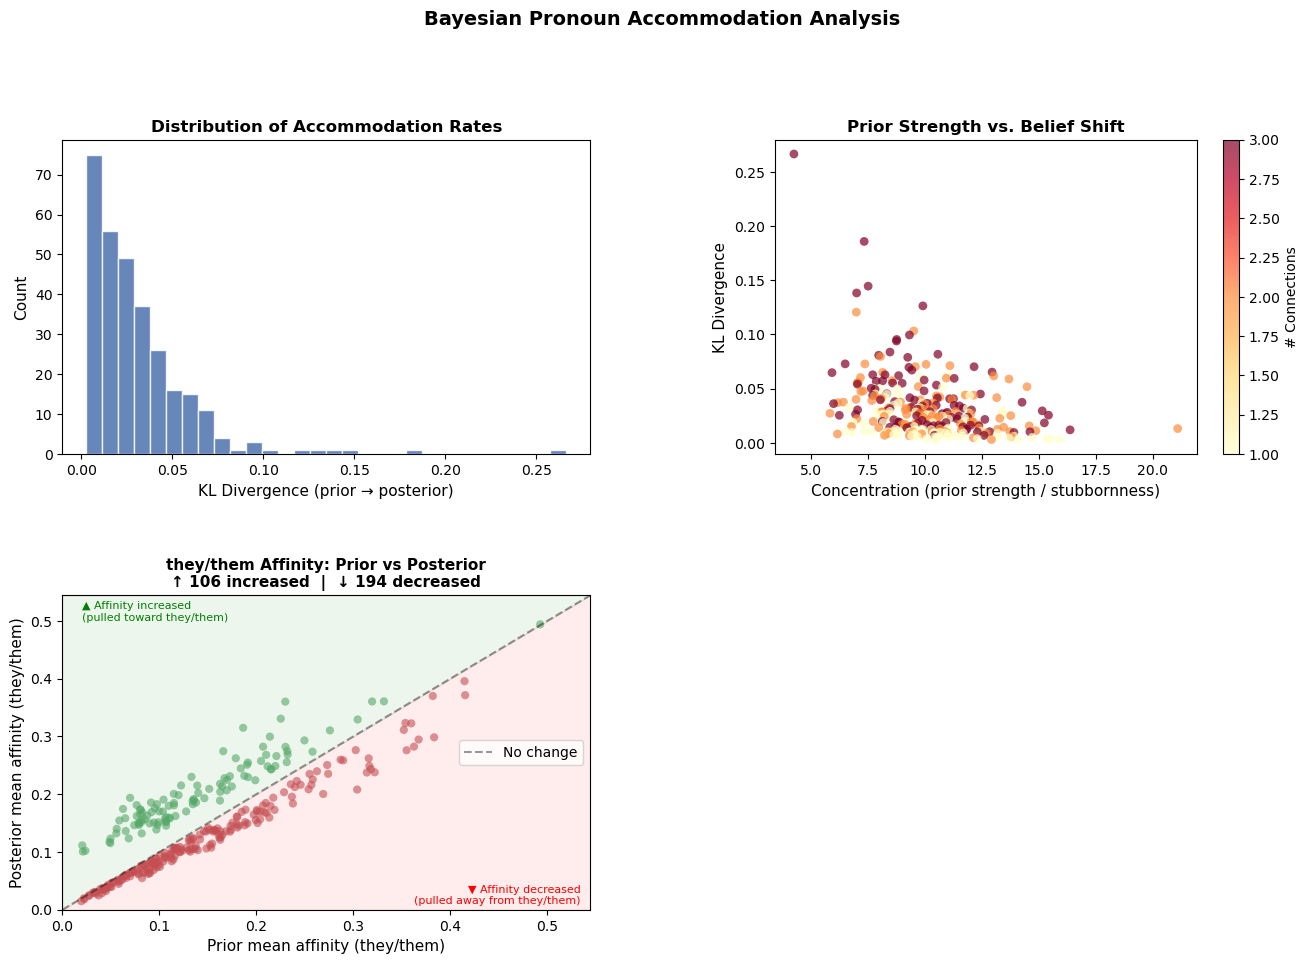

In [20]:
#visualization of accomodation dist
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# kl divergence distribution, how belief change is distributed across data
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(accommodation_df['KL_Divergence'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
ax1.set_xlabel('KL Divergence (prior → posterior)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Distribution of Accommodation Rates', fontsize=12, fontweight='bold')

# concentration vs kl divergence, gives tests for more biased individuals show less belief change
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(
    accommodation_df['Concentration'],
    accommodation_df['KL_Divergence'],
    c=accommodation_df['N_Connections'],
    cmap='YlOrRd', alpha=0.7, edgecolors='none', s=40
)
plt.colorbar(sc, ax=ax2, label='# Connections')
ax2.set_xlabel('Concentration (prior strength / stubbornness)', fontsize=11)
ax2.set_ylabel('KL Divergence', fontsize=11)
ax2.set_title('Prior Strength vs. Belief Shift', fontsize=12, fontweight='bold')

#they them posterior
ax3 = fig.add_subplot(gs[1, 0])

#compute delta and lim
accommodation_df['they_them_delta'] = (
    accommodation_df['post_mean_they_them'] - accommodation_df['prior_mean_they_them']
)
lim_max = accommodation_df[['prior_mean_they_them', 'post_mean_they_them']].max().max() + 0.05

#shaded regions
ax3.fill_between([0, lim_max], [0, lim_max], [lim_max, lim_max],
                 alpha=0.07, color='green')
ax3.fill_between([0, lim_max], [0, 0], [0, lim_max],
                 alpha=0.07, color='red')

#regional labels
ax3.text(0.02, lim_max - 0.01,
         '▲ Affinity increased\n(pulled toward they/them)',
         fontsize=8, color='green', va='top')
ax3.text(lim_max - 0.01, 0.01,
         '▼ Affinity decreased\n(pulled away from they/them)',
         fontsize=8, color='red', ha='right')

#colors by directional change
colors = np.where(
    accommodation_df['they_them_delta'] > 0, '#55A868', '#C44E52'
)
ax3.scatter(
    accommodation_df['prior_mean_they_them'],
    accommodation_df['post_mean_they_them'],
    c=colors, alpha=0.6, s=35, edgecolors='none'
)

# most distinction of where and what people reside above and below
ax3.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.4, label='No change')

# count abv/below title
n_above = (accommodation_df['they_them_delta'] > 0).sum()
n_below = (accommodation_df['they_them_delta'] < 0).sum()

ax3.set_xlabel('Prior mean affinity (they/them)', fontsize=11)
ax3.set_ylabel('Posterior mean affinity (they/them)', fontsize=11)
ax3.set_title(
    f'they/them Affinity: Prior vs Posterior\n↑ {n_above} increased  |  ↓ {n_below} decreased',
    fontsize=11, fontweight='bold'
)
ax3.legend()
ax3.set_xlim(0, lim_max)
ax3.set_ylim(0, lim_max)

plt.suptitle('Bayesian Pronoun Accommodation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.show()


In [ ]:
accommodation_df.to_csv('bayesian_accommodation_results.csv', index=False, encoding='utf-8-sig')
print('Exported: bayesian_accommodation_results.csv')
print(f'\nSummary statistics:')
print(accommodation_df[['Concentration', 'N_Connections', 'KL_Divergence']].describe().round(4))